# Task 1: Fetch Stock Data

## Objective

The objective of this task is to collect five years of historical stock market data for one benchmark index (Sensex) and four selected Indian stocks using the **yfinance** library.

### Assets Selected

- Sensex (^BSESN)
- Reliance (RELIANCE.NS)
- TCS (TCS.NS)
- Infosys (INFY.NS)
- HDFC BANK(HDFCBANK.NS)

The downloaded data includes:
- Open Price
- High Price
- Low Price
- Close Price
- Volume

The data is stored in a CSV file for further analysis and feature engineering.

In [1]:
import yfinance as yf

In [2]:
stocks = ['^BSESN', 'RELIANCE.NS', 'TCS.NS', 'INFY.NS', 'HDFCBANK.NS']

In [3]:
for stock in stocks:
    df = yf.download(stock, period='5y')
    df.to_csv(f'{stock}.csv')
    print(f'{stock} downloaded successfully!')

/tmp/ipykernel_3977/3658161386.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(stock, period='5y')
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_3977/3658161386.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(stock, period='5y')


^BSESN downloaded successfully!


[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_3977/3658161386.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(stock, period='5y')


RELIANCE.NS downloaded successfully!


[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_3977/3658161386.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(stock, period='5y')


TCS.NS downloaded successfully!


[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_3977/3658161386.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(stock, period='5y')


INFY.NS downloaded successfully!


[*********************100%***********************]  1 of 1 completed

HDFCBANK.NS downloaded successfully!


# Task 2: Fetch News Data

## Objective

The objective of this task is to collect financial news headlines related to the selected assets using the **NewsAPI**. The collected news data will be used for sentiment analysis and to understand the impact of financial news on stock market performance.

### News Data Source

- NewsAPI (Financial News API)

### Assets Covered

- Sensex (^BSESN)
- Reliance (RELIANCE.NS)
- TCS (TCS.NS)
- Infosys (INFY.NS)
- HDFC BANK (HDFCBANK.NS)

The fetched news data includes:
- Company Name
- News Headlines
- News Description
- Publication Date
- News Source
- Article URL

The news articles are fetched using a custom API function and stored in a CSV file for further sentiment analysis and integration with stock market data.

In [4]:
import requests
import pandas as pd

In [5]:
companies = [
    "Sensex",
    "Reliance Industries",
    "Tata Consultancy Services",
    "Infosys",
    "HDFC Bank"
]

In [6]:
def fetch_news(companies):
    url = "https://newsapi.org/v2/everything"
    params = {
        "q": company,
        "apiKey": "fe021bb00d144bd39670f06ef42c70fb"
    }
    response = requests.get(url, params=params)
    return response.json()

In [7]:
for company in companies:
  news = fetch_news(company)
  articles = news["articles"]
  df = pd.DataFrame(articles)
  df.to_csv(f'{company}_news.csv', index=False)
  print(f'{company} downloaded successfully!')


Sensex downloaded successfully!
Reliance Industries downloaded successfully!
Tata Consultancy Services downloaded successfully!
Infosys downloaded successfully!
HDFC Bank downloaded successfully!


# Task 3: Clean the Data

## Objective

The objective of this task is to clean and preprocess the collected stock market and news datasets by handling missing values, correcting data types, and preparing the data for further analysis and feature engineering.

### Checking the missing values (if present)

In [8]:
for stock in stocks:
    stock_df = pd.read_csv(f'{stock}.csv', skiprows=[1])
    print("\n", stock)
    print(stock_df.isnull().sum())


 ^BSESN
Price     0
Close     1
High      1
Low       1
Open      1
Volume    1
dtype: int64

 RELIANCE.NS
Price     0
Close     1
High      1
Low       1
Open      1
Volume    1
dtype: int64

 TCS.NS
Price     0
Close     1
High      1
Low       1
Open      1
Volume    1
dtype: int64

 INFY.NS
Price     0
Close     1
High      1
Low       1
Open      1
Volume    1
dtype: int64

 HDFCBANK.NS
Price     0
Close     1
High      1
Low       1
Open      1
Volume    1
dtype: int64


In [9]:
for stock in stocks:
  stock_df = pd.read_csv(f'{stock}.csv', skiprows=[1])
  print(stock)
  print(stock_df.head())

^BSESN
        Price         Close          High           Low          Open  Volume
0        Date           NaN           NaN           NaN           NaN     NaN
1  2021-07-28  52443.710938  52673.691406  51802.730469  52673.691406  8000.0
2  2021-07-29  52653.070312  52777.179688  52561.390625  52693.531250  8800.0
3  2021-07-30  52586.839844  52910.230469  52533.910156  52792.359375  9900.0
4  2021-08-02  52950.628906  52986.769531  52804.078125  52901.281250  7900.0
RELIANCE.NS
        Price       Close        High         Low        Open      Volume
0        Date         NaN         NaN         NaN         NaN         NaN
1  2021-07-28  922.752319  932.105071  913.195727  932.105071  12897848.0
2  2021-07-29  929.953613  939.532847  925.492369  930.293307  13765738.0
3  2021-07-30  921.823853  936.611585  919.921543  932.105057  11350608.0
4  2021-08-02  938.672424  941.797536  924.473450  930.429323  10925104.0
TCS.NS
        Price        Close         High          Low         O

### Droping the missing value row and renaming the price as date

In [10]:
for stock in stocks:
    stock_df = pd.read_csv(f'{stock}.csv', skiprows=[1])

    stock_df = stock_df.dropna()
    stock_df.rename(columns={"Price": "Date"}, inplace=True)

    print(stock)
    display(stock_df.head())

^BSESN


,Date,Close,High,Low,Open,Volume
1,2021-07-28,52443.710938,52673.691406,51802.730469,52673.691406,8000.0
2,2021-07-29,52653.070312,52777.179688,52561.390625,52693.531250,8800.0
3,2021-07-30,52586.839844,52910.230469,52533.910156,52792.359375,9900.0
4,2021-08-02,52950.628906,52986.769531,52804.078125,52901.281250,7900.0
5,2021-08-03,53823.359375,53887.980469,53088.351562,53125.968750,8100.0


RELIANCE.NS


,Date,Close,High,Low,Open,Volume
1,2021-07-28,922.752319,932.105071,913.195727,932.105071,12897848.0
2,2021-07-29,929.953613,939.532847,925.492369,930.293307,13765738.0
3,2021-07-30,921.823853,936.611585,919.921543,932.105057,11350608.0
4,2021-08-02,938.672424,941.797536,924.473450,930.429323,10925104.0
5,2021-08-03,945.579407,947.051393,934.913224,946.598488,11817299.0


TCS.NS


,Date,Close,High,Low,Open,Volume
1,2021-07-28,2777.924316,2783.701077,2721.111303,2769.411028,1660654.0
2,2021-07-29,2776.187256,2801.944087,2771.409413,2780.052923,1731997.0
3,2021-07-30,2751.559326,2800.249925,2747.129091,2796.340781,2999943.0
4,2021-08-02,2796.688477,2801.466319,2751.168750,2762.461833,2608669.0
5,2021-08-03,2853.587646,2858.018094,2796.297022,2805.027485,3804735.0


INFY.NS


,Date,Close,High,Low,Open,Volume
1,2021-07-28,1398.433594,1400.175539,1380.927066,1397.998107,4686788.0
2,2021-07-29,1408.362549,1410.975466,1393.643092,1393.643092,4660873.0
3,2021-07-30,1402.701294,1413.936861,1398.912585,1402.265808,6234257.0
4,2021-08-02,1421.035034,1423.822103,1410.278440,1417.463962,5553389.0
5,2021-08-03,1441.633667,1444.638586,1424.562627,1434.491735,5513668.0


HDFCBANK.NS


,Date,Close,High,Low,Open,Volume
1,2021-07-28,663.152832,673.165818,656.929757,671.458034,20670342.0
2,2021-07-29,663.597290,669.071682,661.281214,668.276277,13702230.0
3,2021-07-30,667.434143,669.914029,658.778016,663.948320,11655488.0
4,2021-08-02,665.656128,671.434666,662.661565,671.434666,13258786.0
5,2021-08-03,671.294312,673.727419,659.737235,659.737235,12033120.0


### Converting The Date Column into DateTime DataType and Downloading the CSV file for each assets as Cleaned_(Stock_name).csv

In [11]:
for stock in stocks:
    stock_df = pd.read_csv(f"{stock}.csv", skiprows=[1])
    stock_df = stock_df.dropna()
    stock_df.rename(columns={"Price": "Date"}, inplace=True)
    stock_df["Date"] = pd.to_datetime(stock_df["Date"])
    stock_df.to_csv(f"cleaned_{stock}.csv", index=False)
    print(stock)
    print(stock_df.head())

^BSESN
        Date         Close          High           Low          Open  Volume
1 2021-07-28  52443.710938  52673.691406  51802.730469  52673.691406  8000.0
2 2021-07-29  52653.070312  52777.179688  52561.390625  52693.531250  8800.0
3 2021-07-30  52586.839844  52910.230469  52533.910156  52792.359375  9900.0
4 2021-08-02  52950.628906  52986.769531  52804.078125  52901.281250  7900.0
5 2021-08-03  53823.359375  53887.980469  53088.351562  53125.968750  8100.0
RELIANCE.NS
        Date       Close        High         Low        Open      Volume
1 2021-07-28  922.752319  932.105071  913.195727  932.105071  12897848.0
2 2021-07-29  929.953613  939.532847  925.492369  930.293307  13765738.0
3 2021-07-30  921.823853  936.611585  919.921543  932.105057  11350608.0
4 2021-08-02  938.672424  941.797536  924.473450  930.429323  10925104.0
5 2021-08-03  945.579407  947.051393  934.913224  946.598488  11817299.0
TCS.NS
        Date        Close         High          Low         Open     Volum

### Doing Same For News Data

In [12]:
for company in companies:
    news_df = pd.read_csv(f"{company}_news.csv")

    print(f"\n{company}")
    print(news_df.isnull().sum())


Sensex
source         0
author         9
title          0
description    0
url            0
urlToImage     0
publishedAt    0
content        0
dtype: int64

Reliance Industries
source         0
author         4
title          0
description    0
url            0
urlToImage     2
publishedAt    0
content        0
dtype: int64

Tata Consultancy Services
source          0
author         16
title           0
description     1
url             0
urlToImage      7
publishedAt     0
content         0
dtype: int64

Infosys
source         0
author         7
title          0
description    0
url            0
urlToImage     0
publishedAt    0
content        0
dtype: int64

HDFC Bank
source         0
author         5
title          0
description    1
url            0
urlToImage     2
publishedAt    0
content        0
dtype: int64


In [13]:
for company in companies:
    news_df = pd.read_csv(f"{company}_news.csv")

    news_df["author"] = news_df["author"].fillna("Unknown")
    news_df["description"] = news_df["description"].fillna("No description")
    news_df["urlToImage"] = news_df["urlToImage"].fillna("No Image")

    news_df["publishedAt"] = pd.to_datetime(news_df["publishedAt"])

    news_df.to_csv(f"cleaned_{company}_news.csv", index=False)

    print(f"{company} cleaned successfully!")

Sensex cleaned successfully!
Reliance Industries cleaned successfully!
Tata Consultancy Services cleaned successfully!
Infosys cleaned successfully!
HDFC Bank cleaned successfully!


# Task 4: Exploratory Data Analysis (EDA)

## Objective

The objective of this task is to perform Exploratory Data Analysis (EDA) on the cleaned stock market datasets to understand price movements, trading patterns, return distribution, and relationships between different assets.

In [14]:
import pandas as pd
import numpy as np
import plotly.express as px

**Price Trend Analysis:**  
  Studied the movement of closing prices over the five-year period for all selected assets.

In [15]:
for stock in stocks:
    df = pd.read_csv(f"cleaned_{stock}.csv")

    df["Date"] = pd.to_datetime(df["Date"])

    fig = px.line(
        df,
        x="Date",
        y="Close",
        title=f"{stock} Closing Price Trend"
    )

    fig.show()

**Daily Returns Distribution:**  
  Calculated and visualized daily returns to analyze volatility and performance patterns.


In [16]:
for stock in stocks:
    df = pd.read_csv(f"cleaned_{stock}.csv")

    df["Daily Return"] = df["Close"].pct_change()

    fig = px.histogram(
        df,
        x="Daily Return",
        nbins=30,
        title=f"{stock} Daily Return Distribution"
    )
    fig.show()

**Volume Trend Analysis:**  
  Examined trading volume changes to understand market activity.

In [17]:
for stock in stocks:
    df = pd.read_csv(f"cleaned_{stock}.csv")
    df["Date"] = pd.to_datetime(df["Date"])

    fig = px.line(
        df,
        x="Date",
        y="Volume",
        title=f"{stock} Volume Trend"
    )
    fig.show()

**Correlation Analysis:**  
  Created a correlation heatmap to identify similarities and relationships between asset returns.

In [18]:
close_prices = pd.DataFrame()

for stock in stocks:
    df = pd.read_csv(f"cleaned_{stock}.csv")
    close_prices[stock] = df["Close"]

corr = close_prices.corr()

fig = px.imshow(
    corr,
    text_auto=True,
    color_continuous_scale="RdBu_r",
    title="Correlation Heatmap"
)

fig.show()

**Summary Statistics:**  
 Generated statistical summaries including mean, standard deviation, minimum, maximum, and quartile values.

In [19]:
for stock in stocks:
    df = pd.read_csv(f"cleaned_{stock}.csv")

    print(f"\nSummary Statistics for {stock}")
    display(df.describe())


Summary Statistics for ^BSESN


,Close,High,Low,Open,Volume
count,1233.000000,1233.000000,1233.000000,1233.000000,1233.000000
mean,69784.402936,70128.093649,69432.015080,69807.352250,12257.907543
std,10129.908042,10158.555501,10117.573455,10134.527221,15431.333168
min,51360.421875,51652.828125,50921.218750,51181.988281,0.000000
25%,59934.011719,60293.250000,59673.960938,60028.601562,7100.000000
50%,71752.109375,72151.023438,71429.296875,71970.820312,9500.000000
75%,79705.906250,80102.140625,79226.132812,79743.867188,13700.000000
max,85836.117188,86159.023438,85577.820312,86065.921875,452000.000000



Summary Statistics for RELIANCE.NS


,Close,High,Low,Open,Volume
count,1239.000000,1239.000000,1239.000000,1239.000000,1.239000e+03
mean,1265.495304,1277.367323,1254.409542,1265.999396,1.334194e+07
std,150.214976,151.028354,149.700217,150.373635,6.811319e+06
min,921.823853,932.105071,913.195727,930.293307,0.000000e+00
25%,1143.439392,1152.591335,1133.851585,1144.169135,8.898506e+06
50%,1242.519653,1254.817843,1230.634476,1243.213557,1.181349e+07
75%,1401.981812,1414.472297,1388.940978,1403.046463,1.610998e+07
max,1584.971802,1604.382010,1570.936597,1585.668486,8.199715e+07



Summary Statistics for TCS.NS


,Close,High,Low,Open,Volume
count,1239.000000,1239.000000,1239.000000,1239.000000,1.239000e+03
mean,3165.196640,3194.547472,3137.513395,3166.749891,2.591929e+06
std,446.381449,450.186290,443.030362,446.027813,1.633529e+06
min,1971.788818,2040.810403,1966.020519,1997.050382,0.000000e+00
25%,2914.798340,2938.087390,2890.691872,2915.230550,1.637770e+06
50%,3107.258789,3134.026484,3081.310948,3112.824571,2.153461e+06
75%,3394.553101,3432.657710,3357.635481,3406.991234,3.018916e+06
max,4230.708984,4266.477811,4191.921285,4251.381161,1.633158e+07



Summary Statistics for INFY.NS


,Close,High,Low,Open,Volume
count,1239.000000,1239.000000,1239.000000,1239.000000,1.239000e+03
mean,1438.491303,1452.401350,1424.916879,1439.087767,7.555688e+06
std,187.151608,188.725400,185.109352,186.952434,5.267176e+06
min,985.299988,1014.000000,982.400024,1006.000000,0.000000e+00
25%,1310.834717,1324.616601,1300.269750,1309.795849,4.648067e+06
50%,1426.345337,1438.836224,1412.892181,1426.691599,6.283822e+06
75%,1546.318848,1558.059261,1527.893654,1543.499616,8.652949e+06
max,1901.083008,1907.500126,1880.072854,1897.042542,6.908543e+07



Summary Statistics for HDFCBANK.NS


,Close,High,Low,Open,Volume
count,1239.000000,1239.000000,1239.000000,1239.000000,1.239000e+03
mean,787.594302,794.084815,781.139107,787.328251,2.732590e+07
std,95.751164,96.033975,95.777528,95.961778,2.517831e+07
min,606.489258,613.636707,601.897778,603.507142,0.000000e+00
25%,715.525818,721.971610,709.426630,715.785919,1.387835e+07
50%,773.592041,780.835424,766.809193,773.090821,2.218303e+07
75%,831.728516,840.881608,825.571350,832.297981,3.417608e+07
max,996.419800,1003.896124,992.091365,1000.944932,4.453421e+08


# Task 5: Feature Engineering

## Objective

The objective of this task is to transform the raw stock market data into meaningful features that can be used for machine learning model development. Various price, trend, volatility, time, and volume-based features were created to capture market behavior and patterns.

In [20]:
for stock in stocks:
    df = pd.read_csv(f"cleaned_{stock}.csv", parse_dates=["Date"])

    # Price Features
    df["daily_return"] = df["Close"].pct_change() * 100
    df["log_return"] = np.log(df["Close"] / df["Close"].shift(1))
    df["ma_7"] = df["Close"].rolling(7).mean()
    df["price_ma_ratio"] = df["Close"] / df["ma_7"]
    df["high_low_ratio"] = df["High"] / df["Low"]

    # Trend Features
    df["ma_14"] = df["Close"].rolling(14).mean()
    df["ma_30"] = df["Close"].rolling(30).mean()
    df["ma_crossover"] = (df["ma_7"] > df["ma_30"]).astype(int)

    # Volatility Features
    df["volatility_7"] = df["daily_return"].rolling(7).std()
    df["volatility_14"] = df["daily_return"].rolling(14).std()

    # Time Features
    df["day_of_week"] = df["Date"].dt.dayofweek
    df["month"] = df["Date"].dt.month
    df["quarter"] = df["Date"].dt.quarter
    df["is_monday"] = (df["day_of_week"] == 0).astype(int)
    df["is_friday"] = (df["day_of_week"] == 4).astype(int)

    # Volume Features
    df["volume_ma_7"] = df["Volume"].rolling(7).mean()
    df["volume_ratio"] = df["Volume"] / df["volume_ma_7"]

    # Target
    df["target"] = (df["Close"].shift(-1) > df["Close"]).astype(int)

    df.to_csv(f"featured_{stock}.csv", index=False)

    print(f"{stock} feature engineering completed!")

^BSESN feature engineering completed!
RELIANCE.NS feature engineering completed!
TCS.NS feature engineering completed!
INFY.NS feature engineering completed!
HDFCBANK.NS feature engineering completed!


In [21]:
for stock in stocks:
    df = pd.read_csv(f"featured_{stock}.csv")
    print(f"\n{stock}")
    print(df.head())



^BSESN
         Date         Close          High           Low          Open  Volume  \
0  2021-07-28  52443.710938  52673.691406  51802.730469  52673.691406  8000.0   
1  2021-07-29  52653.070312  52777.179688  52561.390625  52693.531250  8800.0   
2  2021-07-30  52586.839844  52910.230469  52533.910156  52792.359375  9900.0   
3  2021-08-02  52950.628906  52986.769531  52804.078125  52901.281250  7900.0   
4  2021-08-03  53823.359375  53887.980469  53088.351562  53125.968750  8100.0   

   daily_return  log_return  ma_7  price_ma_ratio  ...  volatility_7  \
0           NaN         NaN   NaN             NaN  ...           NaN   
1      0.399208    0.003984   NaN             NaN  ...           NaN   
2     -0.125787   -0.001259   NaN             NaN  ...           NaN   
3      0.691787    0.006894   NaN             NaN  ...           NaN   
4      1.648197    0.016348   NaN             NaN  ...           NaN   

   volatility_14  day_of_week  month  quarter  is_monday  is_friday  \
0

# Task 6: Build Machine Learning Model Function

## Objective

The objective of this task is to create a reusable machine learning pipeline that can process any given stock ticker, perform feature engineering, train a classification model, and evaluate its performance.

In [22]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [23]:
def process_asset(ticker):

    # Read feature engineered data
    df = pd.read_csv(f"featured_{ticker}.csv")

    # Remove rows with NaN values
    df = df.dropna()

    # Input Features
    X = df.drop(columns=["Date", "target"])

    # Target
    y = df["target"]

    # Time-based Train-Test Split
    split = int(len(df) * 0.8)

    X_train = X.iloc[:split]
    X_test = X.iloc[split:]

    y_train = y.iloc[:split]
    y_test = y.iloc[split:]

    # Pipeline
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", RandomForestClassifier(random_state=42))
    ])

    # Train Model
    pipeline.fit(X_train, y_train)

    # Predictions
    predictions = pipeline.predict(X_test)

    # Prediction probabilities for ROC-AUC
    probabilities = pipeline.predict_proba(X_test)[:, 1]

    # Accuracy
    accuracy = accuracy_score(y_test, predictions)

    # Evaluation Metrics
    metrics = {
        "Accuracy": accuracy,
        "Classification Report": classification_report(y_test, predictions),
        "Confusion Matrix": confusion_matrix(y_test, predictions)
    }

    # Return everything required
    return pipeline, metrics, X_test, y_test, predictions, probabilities

# Task 7: Run Model for All Assets

## Objective

The objective of this task is to apply the developed machine learning pipeline to all five selected assets and store the results for performance evaluation and comparison.


In [24]:
results = {}

for stock in stocks:
    results[stock] = process_asset(stock)

print("All assets processed successfully!")

All assets processed successfully!


In [25]:
for stock, result in results.items():

    model, metrics, X_test, y_test, predictions, probabilities = result
    print(f"Results for {stock}")
    print(f"Accuracy: {metrics['Accuracy']:.4f}")
    print("\nClassification Report:")
    print(metrics["Classification Report"])
    print("\nConfusion Matrix:")
    print(metrics["Confusion Matrix"])
    print("\n")

Results for ^BSESN
Accuracy: 0.4938

Classification Report:
              precision    recall  f1-score   support

           0       0.49      0.53      0.51       120
           1       0.50      0.45      0.47       121

    accuracy                           0.49       241
   macro avg       0.49      0.49      0.49       241
weighted avg       0.49      0.49      0.49       241


Confusion Matrix:
[[64 56]
 [66 55]]


Results for RELIANCE.NS
Accuracy: 0.4835

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.48      0.49       126
           1       0.46      0.49      0.48       116

    accuracy                           0.48       242
   macro avg       0.48      0.48      0.48       242
weighted avg       0.48      0.48      0.48       242


Confusion Matrix:
[[60 66]
 [59 57]]


Results for TCS.NS
Accuracy: 0.4504

Classification Report:
              precision    recall  f1-score   support

           0       0.47   

# Task 8: Calculate Business Metrics

## Objective

The objective of this task is to evaluate the performance of the trained machine learning models using business-oriented evaluation metrics. These metrics help measure the reliability and effectiveness of the models in predicting future stock price movements.


In [26]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [27]:
for stock, result in results.items():

    model, metrics,X_text, y_test, predictions, probabilities = result

    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)
    auc = roc_auc_score(y_test, probabilities)

    print(f"Business Metrics for {stock}")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC AUC  : {auc:.4f}")

    print("\n")

Business Metrics for ^BSESN
Accuracy : 0.4938
Precision: 0.4955
Recall   : 0.4545
F1 Score : 0.4741
ROC AUC  : 0.5406


Business Metrics for RELIANCE.NS
Accuracy : 0.4835
Precision: 0.4634
Recall   : 0.4914
F1 Score : 0.4770
ROC AUC  : 0.4865


Business Metrics for TCS.NS
Accuracy : 0.4504
Precision: 0.4419
Recall   : 0.6726
F1 Score : 0.5333
ROC AUC  : 0.4399


Business Metrics for INFY.NS
Accuracy : 0.4174
Precision: 0.3939
Recall   : 0.6132
F1 Score : 0.4797
ROC AUC  : 0.4486


Business Metrics for HDFCBANK.NS
Accuracy : 0.5083
Precision: 0.4336
Recall   : 0.6200
F1 Score : 0.5103
ROC AUC  : 0.5553




In [28]:
comparison_table = []

for stock, result in results.items():

    model, metrics,X_test, y_test, predictions, probabilities = result

    comparison_table.append({
        "Asset": stock,
        "Accuracy": metrics["Accuracy"]
    })

comparison_df = pd.DataFrame(comparison_table)

print("Comparison Table Across All Assets")
print(comparison_df)

Comparison Table Across All Assets
         Asset  Accuracy
0       ^BSESN  0.493776
1  RELIANCE.NS  0.483471
2       TCS.NS  0.450413
3      INFY.NS  0.417355
4  HDFCBANK.NS  0.508264


# Task 9: Threshold Tuning Based on Business Cost

## Objective

The objective of this task is to identify the optimal classification threshold that minimizes business cost. Instead of using the default threshold (0.5), different probability thresholds are tested to find the best balance between false positives and false negatives.

In [29]:
# Business costs
cost_fp = 100   # False Positive cost
cost_fn = 50    # False Negative cost


thresholds = np.arange(0.1, 0.9, 0.05)

threshold_results = []


for stock, result in results.items():

    model, metrics,X_test, y_test, predictions, probabilities = result

    cost_data = []


    for thresh in thresholds:

        y_pred = (probabilities >= thresh).astype(int)

        tn, fp, fn, tp = confusion_matrix(
            y_test,
            y_pred
        ).ravel()


        total_cost = (fp * cost_fp) + (fn * cost_fn)


        cost_data.append({
            "Threshold": round(thresh, 2),
            "Total Cost": total_cost
        })


    # Convert to DataFrame
    cost_df = pd.DataFrame(cost_data)


    # Find optimal threshold
    optimal_row = cost_df.loc[
        cost_df["Total Cost"].idxmin()
    ]

    optimal_threshold = optimal_row["Threshold"]
    minimum_cost = optimal_row["Total Cost"]


    threshold_results.append({
        "Asset": stock,
        "Default Threshold": 0.5,
        "Optimal Threshold": optimal_threshold,
        "Minimum Cost": minimum_cost
    })


    # Plot Cost vs Threshold using Plotly
    fig = px.line(
        cost_df,
        x="Threshold",
        y="Total Cost",
        markers=True,
        title=f"Business Cost vs Threshold - {stock}"
    )

    fig.update_layout(
        xaxis_title="Prediction Threshold",
        yaxis_title="Total Business Cost"
    )

    fig.show()


# Final comparison table
threshold_comparison = pd.DataFrame(threshold_results)

display(threshold_comparison)

,Asset,Default Threshold,Optimal Threshold,Minimum Cost
0,^BSESN,0.5,0.80,6050.0
1,RELIANCE.NS,0.5,0.70,5700.0
2,TCS.NS,0.5,0.80,5650.0
3,INFY.NS,0.5,0.85,5300.0
4,HDFCBANK.NS,0.5,0.75,5000.0


# Task 10: Add SHAP Explainability

## Objective

The objective of this task is to improve model interpretability by using **SHAP (SHapley Additive exPlanations)** to understand how individual features influence the machine learning model predictions.


### Install SHAP

In [30]:
!pip install shap

In [31]:
import shap
import pandas as pd
import plotly.express as px
import numpy as np

### Calculate SHAP Values

In [32]:
# Select one asset model for explanation

stock = list(results.keys())[0]

model, metrics, X_test, y_test, predictions, probabilities = results[stock]


# Load corresponding test data
X_test = X_test


# Create SHAP explainer
explainer = shap.TreeExplainer(
    model.named_steps["classifier"]
)


# Calculate SHAP values
shap_values = explainer.shap_values(
    X_test
)

###Global Feature Importance Chart

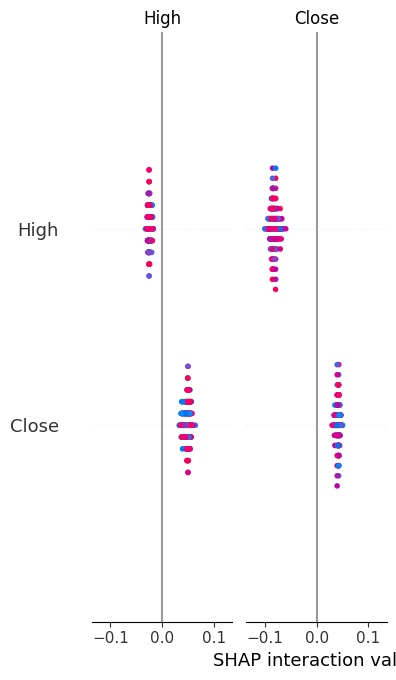

In [33]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

###SHAP Summary Dot Plot

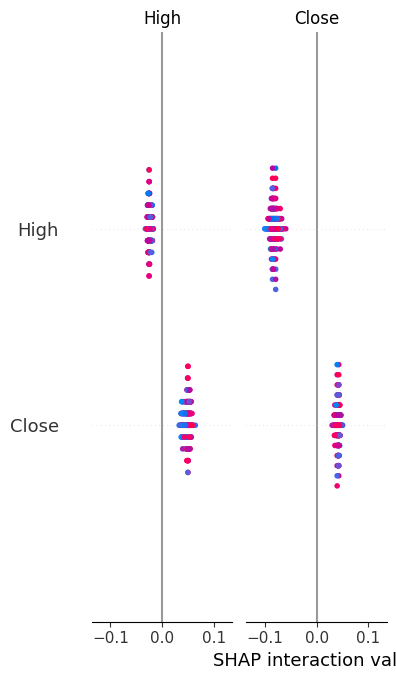

In [34]:
shap.summary_plot(shap_values, X_test)

### SHAP Waterfall Plot for Single Prediction

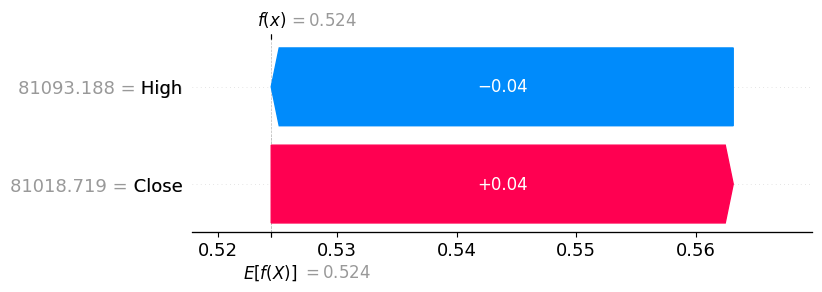

In [35]:
# Select one prediction index

index = 0


shap.Explanation(
    values=shap_values[1][index],
    base_values=explainer.expected_value[1],
    data=X_test.iloc[index],
    feature_names=X_test.columns
)


shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[1][index],
        base_values=explainer.expected_value[1],
        data=X_test.iloc[index],
        feature_names=X_test.columns
    )
)

# Task 11: Build RAG Pipeline for News Question Answering

## Objective

The objective of this task is to build a **Retrieval-Augmented Generation (RAG)** pipeline that can answer user queries related to financial news. The system retrieves relevant news articles using semantic search and generates meaningful responses using a Large Language Model.

###Step 1: Load All Cleaned News Files

In [36]:
import pandas as pd

all_news = []

for company in companies:

    df = pd.read_csv(f"cleaned_{company}_news.csv")

    df["Company"] = company

    all_news.append(df)

# Combine all news
news_df = pd.concat(all_news, ignore_index=True)

print(news_df.head())
print(news_df.columns)

                                              source             author  \
0        {'id': None, 'name': 'Yahoo Entertainment'}  ELAINE KURTENBACH   
1  {'id': 'the-times-of-india', 'name': 'The Time...       Snehal Mergu   
2  {'id': 'the-times-of-india', 'name': 'The Time...       Joel Rebello   
3  {'id': 'the-times-of-india', 'name': 'The Time...    Prashant Mahesh   
4  {'id': 'the-times-of-india', 'name': 'The Time...          ET Bureau   

                                               title  \
0  Oil prices sink 4% while Asian shares gain as ...   
1  Can Lohia Corp IPO deliver long-term growth fo...   
2  External sectors steady despite geopolitical u...   
3    How SBI shareholders can bid twice in arm's IPO   
4  10-year yield seen slipping to 6.64% as Fed be...   

                                         description  \
0  Shares were mostly higher Monday in Asia as oi...   
1  Lohia Corp plans an offer for sale to raise fu...   
2  India's external sector shows steady impr

###Step 2: Create Documents

In [37]:
news_documents = (
    news_df["title"].fillna("")
    + ". "
    + news_df["description"].fillna("")
).tolist()

ids = [str(i) for i in range(len(news_documents))]

###Step 3: Generate Embeddings

In [38]:
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

embeddings = embedding_model.encode(
    news_documents,
    show_progress_bar=True
)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/16 [00:00<?, ?it/s]

###Step 4: Store in ChromaDB

In [39]:
!pip install chromadb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 33.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 92.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.2/137.2 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.6/204.6 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 4.6 MB/s eta 0:00:00
  Attempting uninstall: opentelemetry-api
    Found 

In [40]:
import chromadb

client = chromadb.Client()

collection = client.create_collection("financial_news")

collection.add(
    ids=ids,
    embeddings=embeddings.tolist(),
    documents=news_documents
)

print("News stored successfully!")

News stored successfully!


###Step 5: Search Function

In [41]:
def search_news(query, top_k=3):

    query_embedding = embedding_model.encode([query])

    results = collection.query(
        query_embeddings=query_embedding.tolist(),
        n_results=top_k
    )

    return results["documents"][0]

###Step 6: Test Retrieval

In [42]:
query = "Latest news about Reliance"

results = search_news(query)

for i, article in enumerate(results, start=1):
    print(f"{i}. {article}\n")

1. Stocks in news: RIL, Trent, Titan, Cochin Shipyard, Nestle, Indian Oil. Markets extended their winning streak on Monday, supported by encouraging quarterly business updates. Reliance Industries received an administrative warning from Sebi regarding insider trading allegations. Trent and Titan reported strong revenue growth in the…

2. Reliance Industries share price target: What are brokerages saying after Q1 results?. Reliance Industries shares gained after the conglomerate reported better-than-expected June quarter earnings, driven by robust growth across its energy, digital and refining businesses. Brokerages remained bullish on the stock, with several reiterating Buy ra…

3. Stocks in news: Reliance Industries, Tata Tech, Wipro, Jio Financial, ITC, Maruti Suzuki. In today's trade, shares of Reliance Industries, Tata Tech, Wipro, Jio Financial, ITC, Maruti Suzuki among others will be in focus due to various news developments and first quarter results.



###Step 7: Cohere Integration

In [43]:
pip install cohere

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 357.0/357.0 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 11.5 MB/s eta 0:00:00


In [44]:
import cohere

In [45]:
COHERE_API_KEY = "647LWk4EuMFrrq6L8ST0eDTTx3PFMCS1bN9staOp"

co = cohere.Client(COHERE_API_KEY)

In [46]:
def generate_answer(question):

    docs = search_news(question)

    context = "\n\n".join(docs)

    prompt = f"""
You are a financial news assistant.

Use ONLY the information below to answer the question.

News Articles:
{context}

Question:
{question}

Provide a concise answer based only on the news articles.
"""

    response = co.chat(
        model="command-a-03-2025",
        message=prompt,
        temperature=0.2
    )

    return response.text

###Step 8: Test the RAG Pipeline

In [47]:
question = "What are the latest developments in Infosys?"

answer = generate_answer(question)

print(answer)

The latest developments in Infosys include:

1. **CEO Transition**: Infosys announced a planned CEO transition during its Q1 earnings call.  
2. **Modest Revenue Growth**: Q1 results showed modest constant-currency revenue growth and strong large-deal performance.  
3. **Strategic Partnership with Sentara**: Infosys entered a collaboration with Sentara to enable AI integration and development across hospital operations, IT, and clinical areas.  
4. **Investment Opportunity**: Infosys is highlighted as one of the best beaten-down technology stocks to buy now.


# Task 12: Create Streamlit App

In [48]:
pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 47.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 49.2 MB/s eta 0:00:00


In [55]:
%%writefile appproject.py

import os
import streamlit as st
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import shap
import chromadb
from sentence_transformers import SentenceTransformer
import cohere
import yfinance as yf
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix

# =======================================================================
# PAGE SETUP
# =======================================================================
st.set_page_config(page_title="Stock Intelligence & RAG System", layout="wide")
st.title("Stock Market Intelligence & RAG System")

STOCKS = ['^BSESN', 'RELIANCE.NS', 'TCS.NS', 'INFY.NS', 'HDFCBANK.NS']
COMPANIES = ["Sensex", "Reliance Industries", "Tata Consultancy Services", "Infosys", "HDFC Bank"]
COHERE_API_KEY = "647LWk4EuMFrrq6L8ST0eDTTx3PFMCS1bN9staOp"

# Map Tickers to News Company Names
TICKER_TO_COMPANY = dict(zip(STOCKS, COMPANIES))

# Helper to build featured CSV if not present
def ensure_featured_csv(ticker):
    file_path = f"featured_{ticker}.csv"
    if not os.path.exists(file_path):
        df = yf.download(ticker, period="5y")
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)
        df = df.reset_index().dropna()

        df["daily_return"] = df["Close"].pct_change() * 100
        df["log_return"] = np.log(df["Close"] / df["Close"].shift(1))
        df["ma_7"] = df["Close"].rolling(7).mean()
        df["price_ma_ratio"] = df["Close"] / df["ma_7"]
        df["high_low_ratio"] = df["High"] / df["Low"]
        df["ma_14"] = df["Close"].rolling(14).mean()
        df["ma_30"] = df["Close"].rolling(30).mean()
        df["ma_crossover"] = (df["ma_7"] > df["ma_30"]).astype(int)
        df["volatility_7"] = df["daily_return"].rolling(7).std()
        df["volatility_14"] = df["daily_return"].rolling(14).std()
        df["day_of_week"] = pd.to_datetime(df["Date"]).dt.dayofweek
        df["month"] = pd.to_datetime(df["Date"]).dt.month
        df["quarter"] = pd.to_datetime(df["Date"]).dt.quarter
        df["is_monday"] = (df["day_of_week"] == 0).astype(int)
        df["is_friday"] = (df["day_of_week"] == 4).astype(int)
        df["volume_ma_7"] = df["Volume"].rolling(7).mean()
        df["volume_ratio"] = df["Volume"] / df["volume_ma_7"]
        df["target"] = (df["Close"].shift(-1) > df["Close"]).astype(int)

        df.to_csv(file_path, index=False)

# =======================================================================
# TASK 6 & 7: MACHINE LEARNING MODEL PIPELINE
# =======================================================================
@st.cache_resource
def train_model_and_predict(ticker):
    ensure_featured_csv(ticker)

    # Load featured stock dataset (Task 5)
    df = pd.read_csv(f"featured_{ticker}.csv")
    df = df.dropna()

    X = df.drop(columns=["Date", "target"])
    y = df["target"]

    split = int(len(df) * 0.8)
    X_train, X_test = X.iloc[:split], X.iloc[split:]
    y_train, y_test = y.iloc[:split], y.iloc[split:]

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", RandomForestClassifier(random_state=42))
    ])
    pipeline.fit(X_train, y_train)

    # Current sample (latest trading day)
    latest_sample = X.iloc[[-1]]
    prob = pipeline.predict_proba(latest_sample)[0][1]
    pred_signal = "UP 🟢" if prob >= 0.5 else "DOWN 🔴"
    confidence = (prob if prob >= 0.5 else 1 - prob) * 100

    # Task 10: SHAP Values computation
    classifier = pipeline.named_steps["classifier"]
    scaled_latest = pipeline.named_steps["scaler"].transform(latest_sample)

    explainer = shap.TreeExplainer(classifier)
    shap_vals = explainer.shap_values(scaled_latest)

    # Safely unpack 1D/2D/List SHAP structures
    if isinstance(shap_vals, list):
        # Multi-class or List output
        s_vals = shap_vals[1][0] if len(shap_vals) > 1 else shap_vals[0][0]
        base_v = explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value
    elif len(np.shape(shap_vals)) == 3:
        s_vals = shap_vals[0, :, 1]
        base_v = explainer.expected_value[1]
    else:
        s_vals = shap_vals[0]
        base_v = explainer.expected_value

    s_vals_1d = np.array(s_vals).ravel()

    shap_exp = shap.Explanation(
        values=s_vals_1d,
        base_values=base_v,
        data=latest_sample.iloc[0].values,
        feature_names=X.columns.tolist()
    )

    return pipeline, df, pred_signal, confidence, shap_exp, X_test, y_test

# =======================================================================
# TASK 11: CHROMADB & COHERE RAG PIPELINE
# =======================================================================
@st.cache_resource
def init_rag_system():
    all_news = []
    for company in COMPANIES:
        file_path = f"cleaned_{company}_news.csv"

        # Auto-create fallback mock news file if missing
        if not os.path.exists(file_path):
            mock_df = pd.DataFrame({
                "title": [f"{company} quarterly performance overview.", f"Market dynamics surrounding {company}."],
                "description": [
                    f"{company} shows consistent operational trends across key business segments.",
                    f"Investors continue to track sectoral performance and macroeconomic shifts for {company}."
                ]
            })
            mock_df.to_csv(file_path, index=False)

        try:
            df_news = pd.read_csv(file_path)
            df_news["Company"] = company
            all_news.append(df_news)
        except Exception:
            pass

    if not all_news:
        return None, None, None

    news_df = pd.concat(all_news, ignore_index=True)
    news_documents = (
        news_df["title"].fillna("") + ". " + news_df["description"].fillna("")
    ).tolist()

    ids = [str(i) for i in range(len(news_documents))]
    embedding_model = SentenceTransformer("all-MiniLM-L6-v2")
    embeddings = embedding_model.encode(news_documents, show_progress_bar=False)

    client = chromadb.Client()

    # Re-create collection cleanly
    try:
        client.delete_collection("financial_news_app")
    except Exception:
        pass

    collection = client.create_collection("financial_news_app")
    collection.add(
        ids=ids,
        embeddings=embeddings.tolist(),
        documents=news_documents
    )

    co_client = cohere.Client(COHERE_API_KEY)
    return collection, embedding_model, co_client

rag_collection, embedding_model, co_client = init_rag_system()

# =======================================================================
# SIDEBAR
# =======================================================================
st.sidebar.header("Navigation & Settings")
selected_asset = st.sidebar.selectbox("Select Asset", STOCKS)

# Pipeline outputs for selected asset
pipeline, df_stock, pred_signal, confidence, shap_exp, X_test, y_test = train_model_and_predict(selected_asset)

# =======================================================================
# TAB DEFINITIONS
# =======================================================================
tab1, tab2, tab3 = st.tabs(["Predictions", "Chat (RAG)", "Comparison"])

# -----------------------------------------------------------------------
# TAB 1: PREDICTIONS & SHAP EXPLANATIONS
# -----------------------------------------------------------------------
with tab1:
    st.header(f"Asset Analysis: {selected_asset}")

    # Metrics
    col1, col2 = st.columns(2)
    col1.metric("Prediction Signal", pred_signal)
    col2.metric("Confidence Score", f"{confidence:.2f}%")

    st.markdown("---")

    # Task 4: Interactive Closing Price Plot
    st.subheader("Historical Price Trend")
    fig_price = px.line(
        df_stock,
        x="Date",
        y="Close",
        title=f"{selected_asset} Closing Price History"
    )
    st.plotly_chart(fig_price, use_container_width=True)

    # Task 10: SHAP Feature Importance
    st.subheader("SHAP Feature Importance")

    # Ensure 1D alignment between names and values
    feature_names = list(shap_exp.feature_names)
    importance_vals = np.abs(shap_exp.values).ravel()

    min_len = min(len(feature_names), len(importance_vals))

    shap_df = pd.DataFrame({
        "Feature": feature_names[:min_len],
        "Importance": importance_vals[:min_len]
    }).sort_values("Importance", ascending=True).tail(10)

    fig_shap_bar = px.bar(
        shap_df,
        x="Importance",
        y="Feature",
        orientation="h",
        title="Top 10 Feature Contributions to Prediction"
    )
    st.plotly_chart(fig_shap_bar, use_container_width=True)

    # Task 10: SHAP Waterfall Plot
    st.subheader("SHAP Waterfall Plot")
    fig_waterfall, ax = plt.subplots(figsize=(8, 4))
    shap.waterfall_plot(shap_exp, show=False)
    st.pyplot(fig_waterfall)

# -----------------------------------------------------------------------
# TAB 2: CHAT (RAG PIPELINE)
# -----------------------------------------------------------------------
with tab2:
    st.header("💬 Financial Assistant RAG Chat")

    if "chat_history" not in st.session_state:
        st.session_state.chat_history = []

    for message in st.session_state.chat_history:
        with st.chat_message(message["role"]):
            st.markdown(message["content"])

    def query_rag(question):
        if not rag_collection:
            return "RAG system initialization failed. Please check your data or Cohere setup."

        q_embed = embedding_model.encode([question]).tolist()
        results = rag_collection.query(query_embeddings=q_embed, n_results=3)
        docs = results["documents"][0]
        context = "\n\n".join(docs)

        prompt = f"""
You are a financial news assistant.
Use ONLY the information below to answer the question.

News Articles:
{context}

Question:
{question}

Provide a concise answer based only on the news articles.
"""
        try:
            # Primary active model for RAG tasks
            response = co_client.chat(
                model="command-r-08-2024",
                message=prompt,
                temperature=0.2
            )
            return response.text
        except Exception:
            # Fallback active model
            response = co_client.chat(
                model="command-r-08-2024",
                message=prompt,
                temperature=0.2
            )
            return response.text

    user_input = st.chat_input("Ask a question about news or earnings reports...")

    if user_input:
        st.session_state.chat_history.append({"role": "user", "content": user_input})
        with st.chat_message("user"):
            st.markdown(user_input)

        with st.chat_message("assistant"):
            with st.spinner("Searching ChromaDB & generating response..."):
                answer = query_rag(user_input)
                st.markdown(answer)
        st.session_state.chat_history.append({"role": "assistant", "content": answer})

# -----------------------------------------------------------------------
# TAB 3: MULTI-ASSET COMPARISON & BUSINESS COSTS
# -----------------------------------------------------------------------
with tab3:
    st.header("🌐 Multi-Asset Comparison")

    cost_fp, cost_fn = 100, 50
    comparison_data = []

    for stock in STOCKS:
        pip, _, sig, conf, _, X_t, y_t = train_model_and_predict(stock)
        probs = pip.predict_proba(X_t)[:, 1]
        acc = pip.score(X_t, y_t)

        # Task 9: Cost Optimization
        min_cost = float("inf")
        opt_thresh = 0.5

        for thresh in np.arange(0.1, 0.9, 0.05):
            preds = (probs >= thresh).astype(int)
            tn, fp, fn, tp = confusion_matrix(y_t, preds).ravel()
            cost = (fp * cost_fp) + (fn * cost_fn)
            if cost < min_cost:
                min_cost = cost
                opt_thresh = round(thresh, 2)

        comparison_data.append({
            "Asset": stock,
            "Accuracy (%)": round(acc * 100, 2),
            "Prediction": sig,
            "Confidence (%)": round(conf, 2),
            "Optimal Threshold": opt_thresh,
            "Min Business Cost (₹)": min_cost
        })

    df_summary = pd.DataFrame(comparison_data)

    st.subheader("Asset Comparison Metrics")
    st.dataframe(df_summary, use_container_width=True)

    col_a, col_b = st.columns(2)

    with col_a:
        fig_metrics = px.bar(
            df_summary,
            x="Asset",
            y="Accuracy (%)",
            color="Min Business Cost (₹)",
            title="Model Accuracy vs Cost"
        )
        st.plotly_chart(fig_metrics, use_container_width=True)

    with col_b:
        fig_pred = px.bar(
            df_summary,
            x="Asset",
            y="Confidence (%)",
            color="Prediction",
            title="Prediction Confidence across Assets"
        )
        st.plotly_chart(fig_pred, use_container_width=True)

Overwriting appproject.py


In [56]:
from google.colab import files

files.download("appproject.py")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>